<a href="https://colab.research.google.com/github/shiva13912/csit02/blob/main/CNN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cell 1- Imports


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

Cell 2 — Dataset

In [ ]:
BATCH_SIZE = 64

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train Images:", len(train_dataset))
print("Test Images:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.83MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.57MB/s]

Train Images: 60000
Test Images: 10000


Cell 3 — CNN Model

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self,x):
        x = self.conv(x)
        x = self.fc(x)
        return x

model = CNN().to(device)

print(model)

CNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


Cell 4 — Training Setup

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

Cell 5 — Training

In [ ]:
EPOCHS = 5

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch 1/5 Loss: 0.1364
Epoch 2/5 Loss: 0.0448
Epoch 3/5 Loss: 0.0301
Epoch 4/5 Loss: 0.0216
Epoch 5/5 Loss: 0.0188


Cell 6 — Save Model

In [ ]:
torch.save(
    model.state_dict(),
    "digit_model.pt"
)

print("Model Saved")

Model Saved


Cell 7 — Evaluate Accuracy

In [ ]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

accuracy = 100 * correct / total

print(
    f"Accuracy: {accuracy:.2f}%"
)

Accuracy: 99.04%


Cell 8 — Download Model

In [ ]:
from google.colab import files

files.download("digit_model.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cell 9 — Upload Image

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving digit.png to digit (6).png


Cell 10 — Predict Image

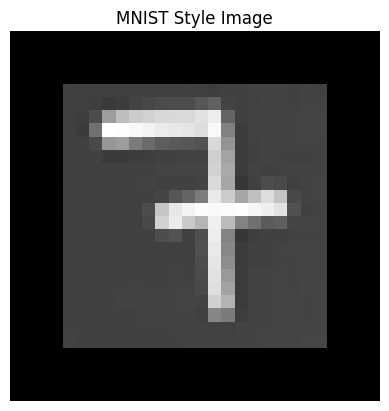

Predicted Digit = 7

Confidence Scores:
0: 0.01%
1: 0.40%
2: 5.30%
3: 19.77%
4: 0.74%
5: 0.01%
6: 0.01%
7: 71.19%
8: 2.44%
9: 0.14%


In [ ]:
from PIL import Image, ImageOps
import numpy as np
import torch
import matplotlib.pyplot as plt

# Load image
img = Image.open("digit (6).png").convert("L")

# Invert: white digit on black background
img = ImageOps.invert(img)

# Crop digit tightly
arr = np.array(img)
rows, cols = np.where(arr > 20)

if len(rows) > 0:
    arr = arr[
        rows.min():rows.max()+1,
        cols.min():cols.max()+1
    ]

# Resize while preserving digit
img = Image.fromarray(arr)
img = img.resize((20, 20))

# Put digit in center of 28x28 image
canvas = np.zeros((28, 28), dtype=np.uint8)

start_x = (28 - 20) // 2
start_y = (28 - 20) // 2

canvas[start_y:start_y+20,
       start_x:start_x+20] = np.array(img)

# Show processed image
plt.imshow(canvas, cmap="gray")
plt.title("MNIST Style Image")
plt.axis("off")
plt.show()

# Normalize
canvas = canvas.astype(np.float32) / 255.0
canvas = (canvas - 0.1307) / 0.3081

tensor = torch.tensor(canvas).unsqueeze(0).unsqueeze(0).to(device)

# Predict
model.eval()

with torch.no_grad():
    output = model(tensor)
    probs = torch.softmax(output, dim=1)[0]

pred = torch.argmax(probs).item()

print("Predicted Digit =", pred)

print("\nConfidence Scores:")
for i, p in enumerate(probs):
    print(f"{i}: {p.item()*100:.2f}%")

# New Section